In [1]:
!pip install bertopic sentence-transformers

In [2]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import numpy as np

url = 'https://raw.githubusercontent.com/alexanderthefourth/ReviewDigest/main/clean_steam_dataset.csv'
df = pd.read_csv(url)

print(df['app_name'].value_counts())
print(f"Ukupno: {len(df)}")

app_name
PAYDAY 2              9999
Dota 2                9997
Grand Theft Auto V    9993
Warframe              7252
Arma 3                5919
Name: count, dtype: int64
Ukupno: 43160


In [3]:
#Pre pokretanja:
# Runtime → Change runtime type → T4 GPU
# Pokreni ćelije redom od Cell 0

#Napomena: embeddings.npy se generiše lokalno na Google Drive-u pri prvom pokretanju

from google.colab import drive
drive.mount('/content/drive')

model = SentenceTransformer('all-MiniLM-L6-v2')
docs = df['review_text'].tolist()


embeddings_path = '/content/drive/MyDrive/ReviewDigest/embeddings.npy'

import os
os.makedirs('/content/drive/MyDrive/ReviewDigest', exist_ok=True)


if os.path.exists(embeddings_path):
    print("Učitavam postojeće embeddings...")
    embeddings = np.load(embeddings_path)
    print(f"Učitano! Shape: {embeddings.shape}")
else:
    print("Računam embeddings (prvi put, trajaće ~10-15 min)...")
    embeddings = model.encode(docs, show_progress_bar=True, batch_size=64)
    np.save(embeddings_path, embeddings)
    print(f"Sačuvano! Shape: {embeddings.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Učitavam postojeće embeddings...
Učitano! Shape: (43160, 384)


In [4]:
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

games = df['app_name'].unique()
game_models = {}
game_topics = {}

for game in games:
    print(f"\nObrađujem: {game}")
    idx = df[df['app_name'] == game].index
    game_docs = df.loc[idx, 'review_text'].tolist()
    game_embeddings = embeddings[idx]

    vectorizer = CountVectorizer(stop_words="english", min_df=5)
    ctfidf = ClassTfidfTransformer(reduce_frequent_words=True)

    model_game = BERTopic(
        vectorizer_model=vectorizer,
        ctfidf_model=ctfidf,
        nr_topics=8,
        calculate_probabilities=False,
        verbose=False
    )

    topics, _ = model_game.fit_transform(game_docs, game_embeddings)
    game_models[game] = model_game
    game_topics[game] = topics

    print(game_models[game].get_topic_info().head(10))


Obrađujem: PAYDAY 2
   Topic  Count                                  Name  \
0     -1   4192         -1_payday_overkill_money_just   
1      0   5458  0_microtransactions_dlc_friends_play   
2      1    171                 1_1010_nice_bank_1110   
3      2     77             2_drill_thermal_1010_bain   
4      3     63          3_simulator_bags_1010_fixing   
5      4     14            4_jammed_guys_drill_drills   
6      5     14               5_left_1110_kick_reason   
7      6     10              6_cash_almir_forget_grab   

                                      Representation  \
0  [payday, overkill, money, just, time, dont, co...   
1  [microtransactions, dlc, friends, play, fun, g...   
2  [1010, nice, bank, 1110, friend, pay, kill, po...   
3  [drill, thermal, 1010, bain, simulator, 1110, ...   
4  [simulator, bags, 1010, fixing, drills, gold, ...   
5  [jammed, guys, drill, drills, fix, chains, bai...   
6  [left, 1110, kick, reason, thanks, kicking, st...   
7  [cash, almir, 

In [5]:
df['topic'] = -1

for game in games:
    idx = df[df['app_name'] == game].index
    df.loc[idx, 'topic'] = game_topics[game]

print(df.groupby(['app_name', 'topic']).size())

app_name            topic
Arma 3              -1       2678
                     0       1967
                     1        501
                     2        352
                     3        291
                     4         71
                     5         46
                     6         13
Dota 2              -1       4661
                     0       5139
                     1         55
                     2         49
                     3         29
                     4         25
                     5         22
                     6         17
Grand Theft Auto V  -1       4649
                     0       4956
                     1        288
                     2         47
                     3         16
                     4         13
                     5         13
                     6         11
PAYDAY 2            -1       4192
                     0       5458
                     1        171
                     2         77
                     3

In [7]:
df_topics = df[df['topic'] != -1].copy()

for game in games:
    print(f"\n{'='*60}")
    print(f"{game}")
    print('='*60)

    game_df = df_topics[df_topics['app_name'] == game].copy()

    topic_info = game_models[game].get_topic_info()
    topic_info = topic_info[topic_info['Topic'] != -1][['Topic', 'Name']]
    game_df = game_df.merge(topic_info, left_on='topic', right_on='Topic')

    sentiment = game_df.groupby(['Name', 'review_score']).size().unstack(fill_value=0)
    sentiment.columns = ['negativne', 'pozitivne']
    sentiment['ukupno'] = sentiment['negativne'] + sentiment['pozitivne']
    sentiment['pct_pozitivnih'] = (sentiment['pozitivne'] / sentiment['ukupno'] * 100).round(1)
    sentiment = sentiment.sort_values('pct_pozitivnih', ascending=False)

    print(sentiment[['pozitivne', 'negativne', 'ukupno', 'pct_pozitivnih']])


PAYDAY 2
                                      pozitivne  negativne  ukupno  \
Name                                                                 
1_1010_nice_bank_1110                       168          3     171   
3_simulator_bags_1010_fixing                 57          6      63   
2_drill_thermal_1010_bain                    66         11      77   
4_jammed_guys_drill_drills                   11          3      14   
5_left_1110_kick_reason                       8          6      14   
0_microtransactions_dlc_friends_play       2693       2765    5458   
6_cash_almir_forget_grab                      0         10      10   

                                      pct_pozitivnih  
Name                                                  
1_1010_nice_bank_1110                           98.2  
3_simulator_bags_1010_fixing                    90.5  
2_drill_thermal_1010_bain                       85.7  
4_jammed_guys_drill_drills                      78.6  
5_left_1110_kick_reason      

In [8]:
import re

def clean_topic_name(name):
    name = re.sub(r'^\d+_', '', name)
    name = re.sub(r'\d+', '', name)
    name = name.replace('_', ' ').strip()
    name = re.sub(r'\s+', ' ', name).strip()
    return name

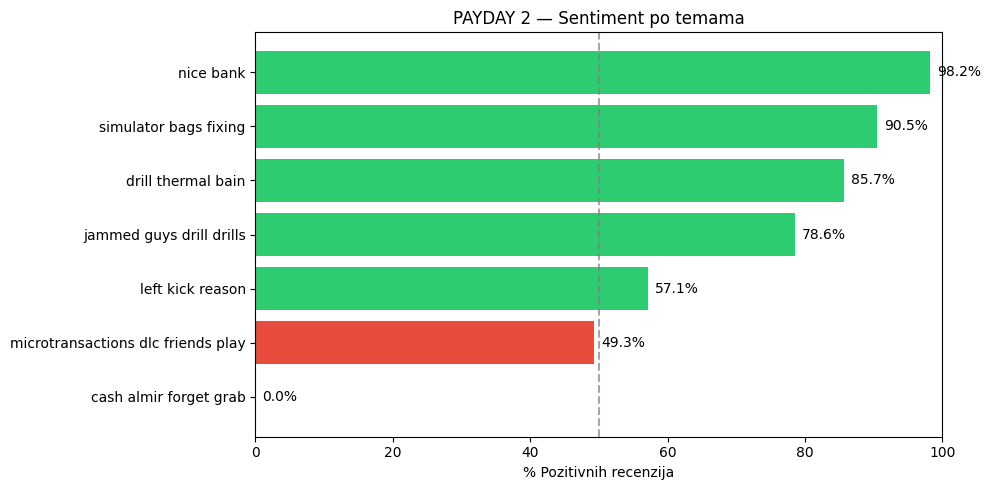

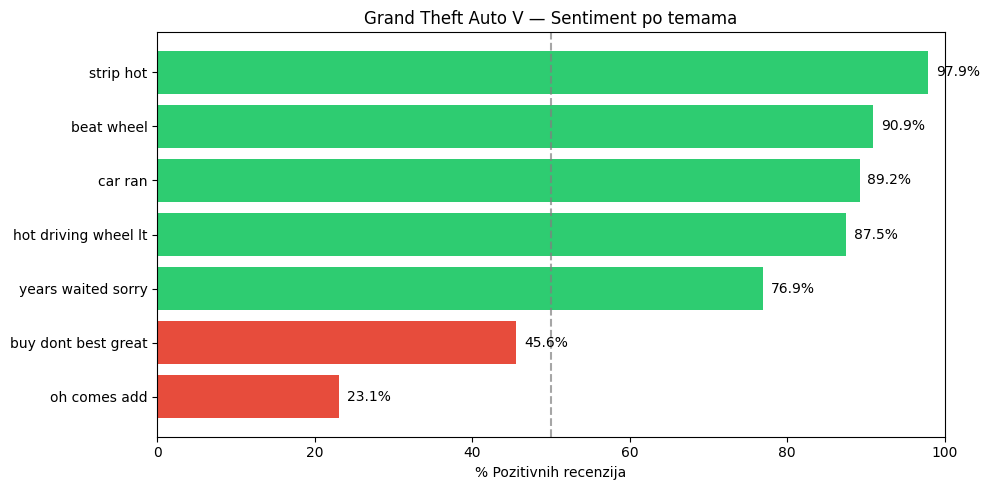

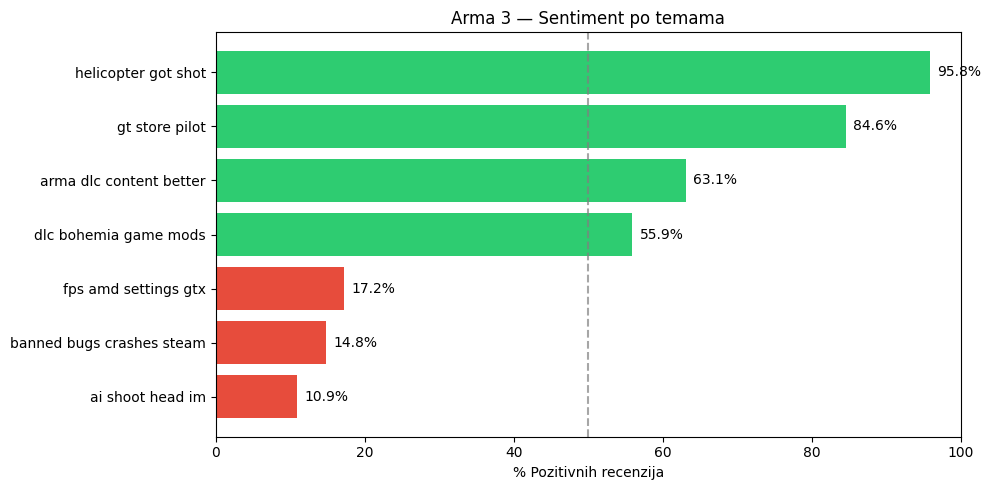

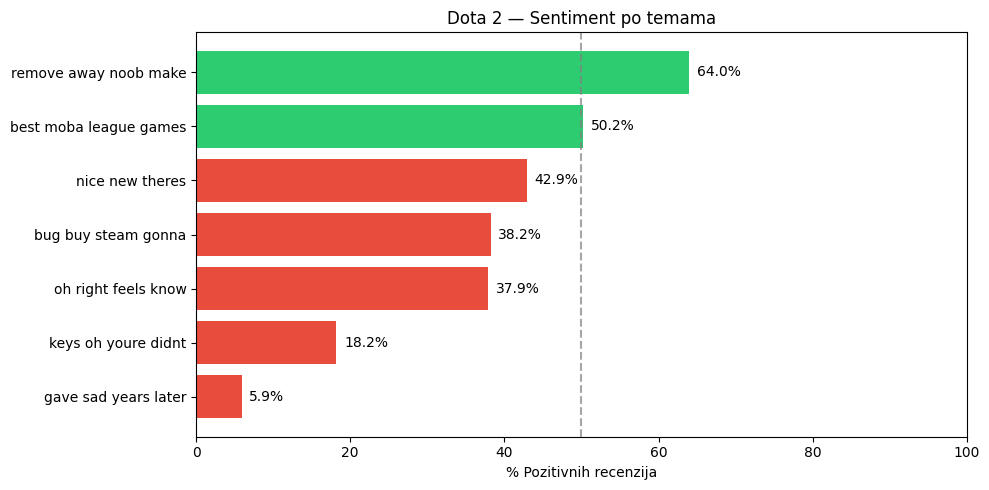

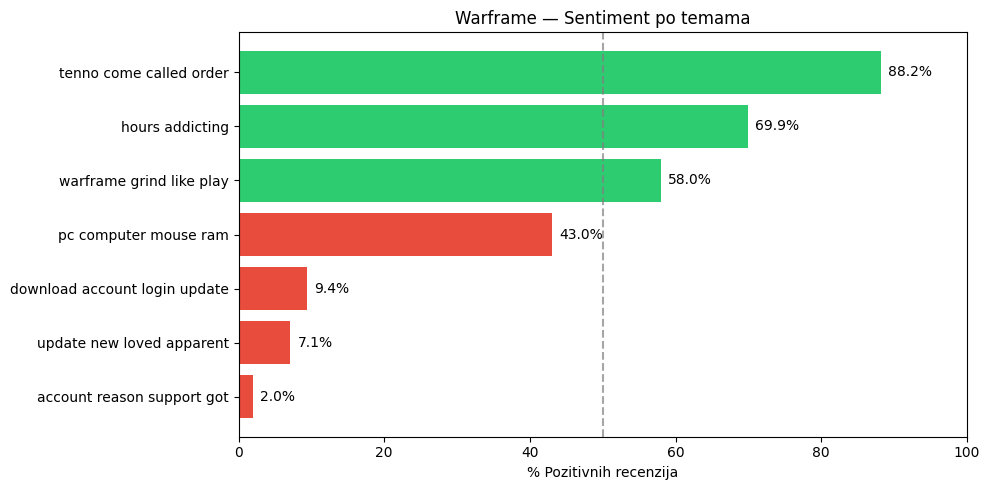

In [9]:
import matplotlib.pyplot as plt

df_topics = df[df['topic'] != -1].copy()

for game in games:
    game_df = df_topics[df_topics['app_name'] == game].copy()
    topic_info = game_models[game].get_topic_info()
    topic_info = topic_info[topic_info['Topic'] != -1][['Topic', 'Name']]
    game_df = game_df.merge(topic_info, left_on='topic', right_on='Topic')

    sentiment = game_df.groupby(['Name', 'review_score']).size().unstack(fill_value=0)
    sentiment.columns = ['negativne', 'pozitivne']
    sentiment['pct_pozitivnih'] = (sentiment['pozitivne'] / (sentiment['pozitivne'] + sentiment['negativne']) * 100).round(1)
    sentiment = sentiment.sort_values('pct_pozitivnih', ascending=True)

    sentiment.index = [clean_topic_name(name) for name in sentiment.index]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(sentiment.index, sentiment['pct_pozitivnih'], color=[
        '#e74c3c' if x < 50 else '#2ecc71' for x in sentiment['pct_pozitivnih']
    ])
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.7)
    ax.set_xlabel('% Pozitivnih recenzija')
    ax.set_title(f'{game} — Sentiment po temama')
    ax.set_xlim(0, 100)

    for bar, val in zip(bars, sentiment['pct_pozitivnih']):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/ReviewDigest/{game}_sentiment_clean.png', dpi=150)
    plt.show()

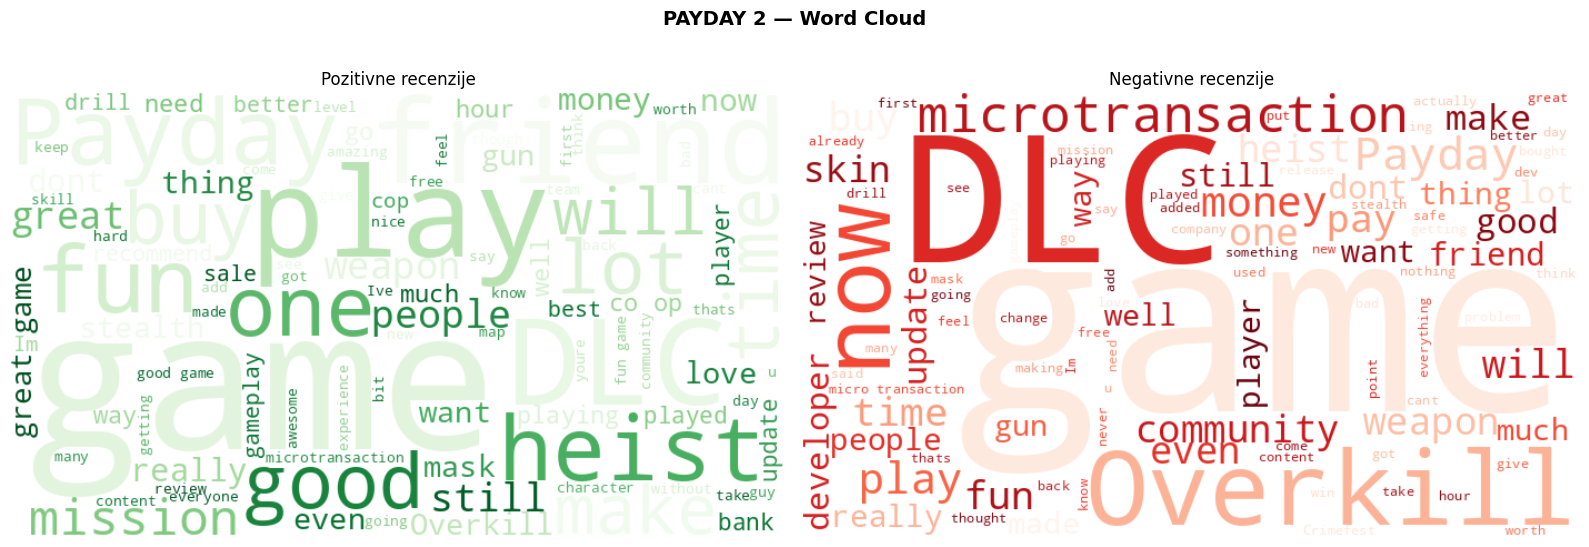

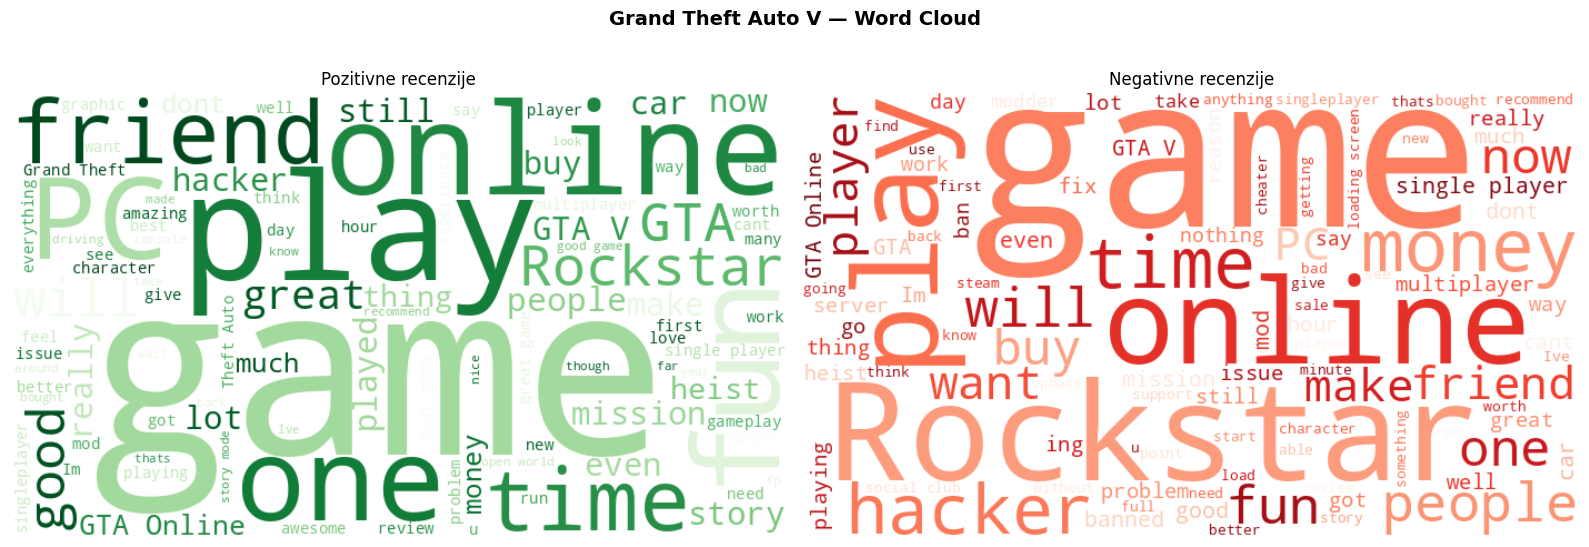

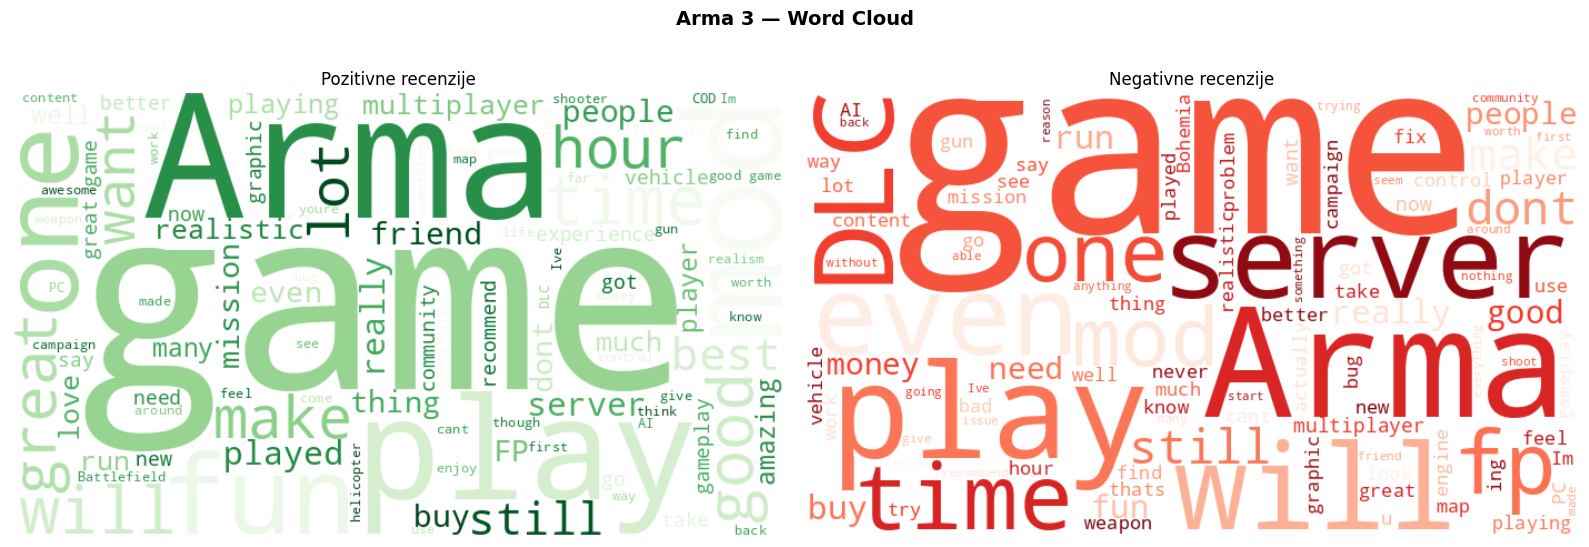

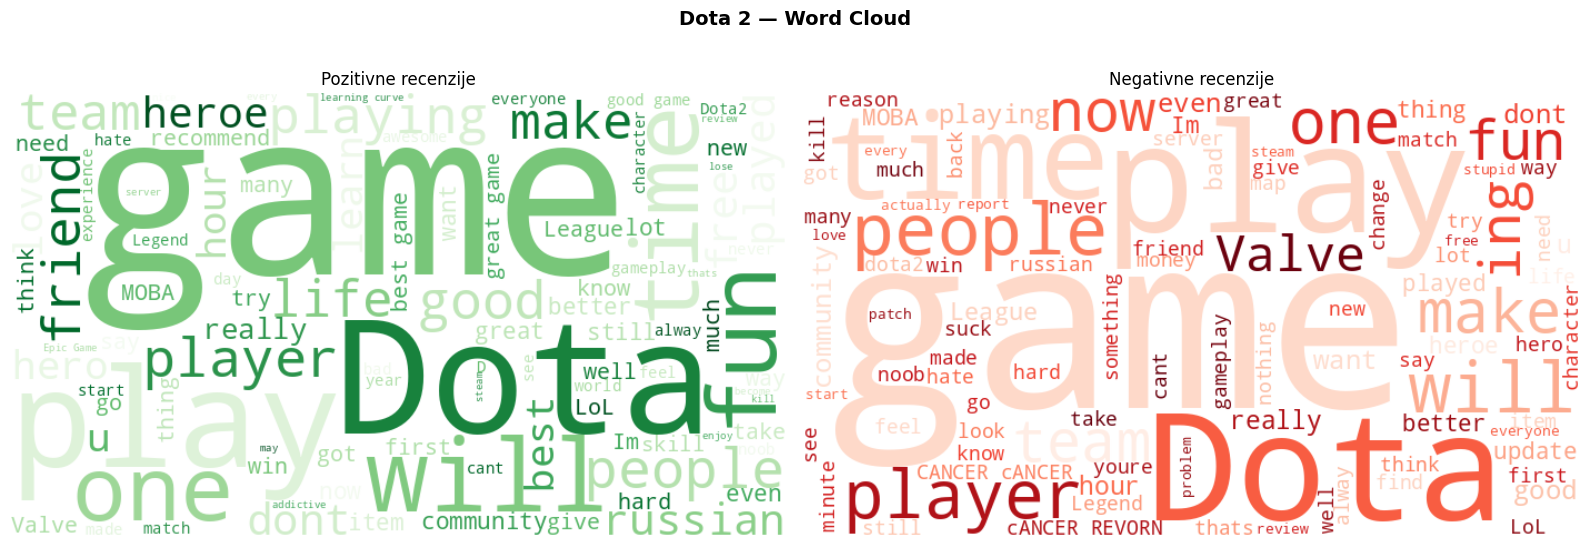

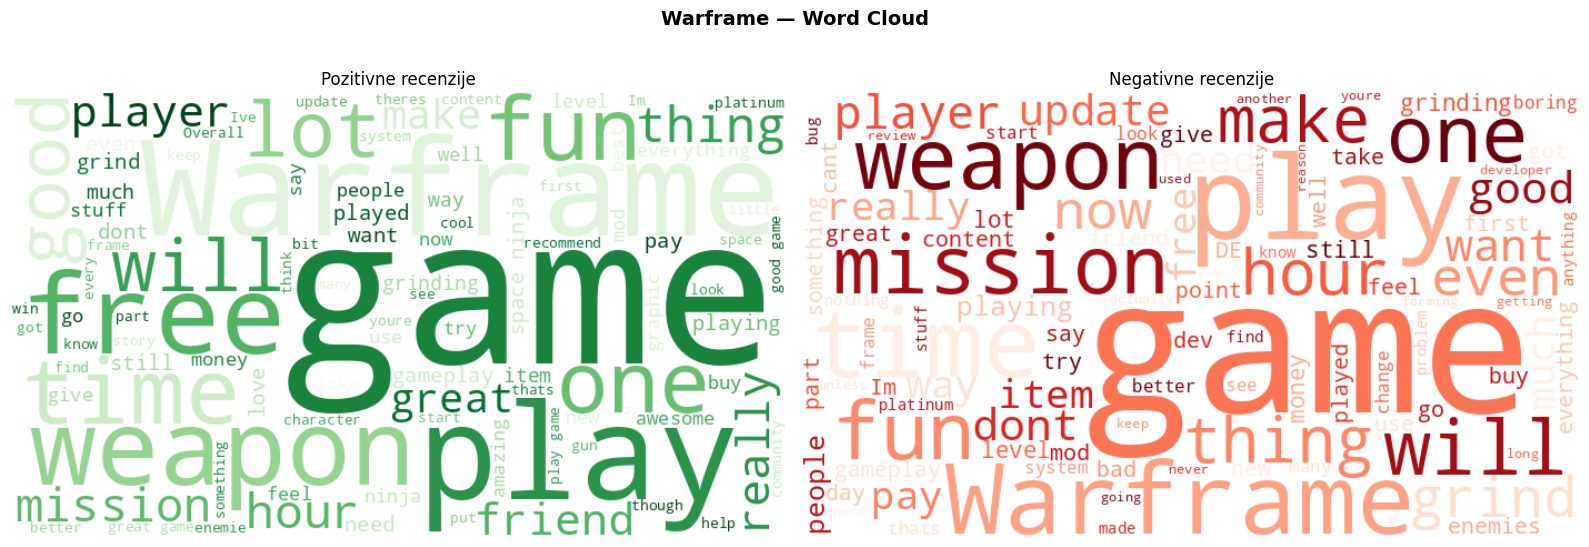

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for game in games:
    game_df = df[df['app_name'] == game]

    pos_text = ' '.join(game_df[game_df['review_score'] == 1]['review_text'])
    neg_text = ' '.join(game_df[game_df['review_score'] == -1]['review_text'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{game} — Word Cloud', fontsize=14, fontweight='bold')

    wc_pos = WordCloud(width=700, height=400, background_color='white',
                       colormap='Greens', stopwords=None,
                       max_words=100).generate(pos_text)

    wc_neg = WordCloud(width=700, height=400, background_color='white',
                       colormap='Reds', stopwords=None,
                       max_words=100).generate(neg_text)

    axes[0].imshow(wc_pos, interpolation='bilinear')
    axes[0].set_title('Pozitivne recenzije', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(wc_neg, interpolation='bilinear')
    axes[1].set_title('Negativne recenzije', fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/ReviewDigest/{game}_wordcloud.png', dpi=150)
    plt.show()